In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import shap
import sys
import os
from tqdm import tqdm

project_root = os.path.dirname(os.path.abspath(''))
if project_root not in sys.path:
    sys.path.append(project_root)

from FEATURES.features import *
from MODELS.pipeline import *
from MODELS.xgboostModel import *
from MODELS.ngboostModel import *

c:\Users\alexg\OneDrive\Documents\NBA-Prop-Predictor\nba_model\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [14]:

pd.set_option('display.max_columns', None)

# s19 = pd.read_csv('../DATA/CSV_FILES/TRAIN_DATA/PTS_TRAIN_19.csv')
s20 = pd.read_csv('../DATA/CSV_FILES/TRAIN_DATA/PTS_TRAIN_20.csv')
s21 = pd.read_csv('../DATA/CSV_FILES/TRAIN_DATA/PTS_TRAIN_21.csv')
s22 = pd.read_csv('../DATA/CSV_FILES/TRAIN_DATA/PTS_TRAIN_22.csv')
s23 = pd.read_csv('../DATA/CSV_FILES/TRAIN_DATA/PTS_TRAIN_23.csv')
s24 = pd.read_csv('../DATA/CSV_FILES/TRAIN_DATA/PTS_TRAIN_24.csv')
s25 = pd.read_csv('../DATA/CSV_FILES/TRAIN_DATA/PTS_TRAIN_25.csv')
s26 = pd.read_csv('../DATA/CSV_FILES/TRAIN_DATA/PTS_TRAIN_26.csv')
for df in [s20,s21,s22,s23,s24,s25,s26]:
    df['IS_HIGH_SCORER'] = (df.groupby('PLAYER_ID')['PTS_AVG_TO_DATE'].transform('mean') > 18).astype(int)

def cap_outliers_per_player(df, target_col='PTS', p_low=0.01, p_high=0.99):
    """Cap target values at specified percentiles per player."""
    df_capped = df.copy()
    for player_id in df_capped['PLAYER_ID'].unique():
        mask = df_capped['PLAYER_ID'] == player_id
        p_low_val = df_capped.loc[mask, target_col].quantile(p_low)
        p_high_val = df_capped.loc[mask, target_col].quantile(p_high)
        df_capped.loc[mask, target_col] = df_capped.loc[mask, target_col].clip(p_low_val, p_high_val)
        print(f"Player {player_id}: PTS range capped [{p_low_val:.1f}, {p_high_val:.1f}]")
    return df_capped

# Training data
train_df = pd.concat([s20,s21,s22,s23,s24,s25,s26])
train_df = train_df[train_df['MIN'] > 10]  
train_df = cap_outliers_per_player(train_df, 'PTS', p_low=0.01, p_high=0.99)

# Validation data
# val_df = s25
# val_df = val_df[val_df['MIN'] > 10] 
# val_df = cap_outliers_per_player(val_df, 'PTS', p_low=0.01, p_high=0.99)

print(f"Train set: {len(train_df)} samples")
# print(f"Val set: {len(val_df)} samples")
# print(f"Test set: {len(test_df)} samples")
train_df.sample(5)

C:\Users\alexg\AppData\Local\Temp\ipykernel_18968\2045709813.py:10: DtypeWarning: Columns (33) have mixed types. Specify dtype option on import or set low_memory=False.
  s26 = pd.read_csv('../DATA/CSV_FILES/TRAIN_DATA/PTS_TRAIN_26.csv')


Player 203458: PTS range capped [0.0, 20.3]
Player 1628981: PTS range capped [0.0, 18.9]
Player 1629629: PTS range capped [0.0, 27.3]
Player 1629631: PTS range capped [2.0, 27.7]
Player 1627761: PTS range capped [0.0, 21.0]
Player 202323: PTS range capped [0.0, 10.7]
Player 203953: PTS range capped [3.0, 30.1]
Player 1628381: PTS range capped [4.0, 34.0]
Player 1628989: PTS range capped [0.0, 28.0]
Player 1629027: PTS range capped [7.0, 47.0]
Player 1713: PTS range capped [0.0, 16.0]
Player 1627745: PTS range capped [0.0, 22.6]
Player 1627820: PTS range capped [0.0, 11.5]
Player 203459: PTS range capped [0.0, 16.9]
Player 202718: PTS range capped [0.1, 7.9]
Player 1629164: PTS range capped [0.0, 21.0]
Player 1629718: PTS range capped [0.1, 7.8]
Player 1628778: PTS range capped [0.0, 28.4]
Player 201952: PTS range capped [0.0, 31.7]
Player 1626203: PTS range capped [0.0, 12.6]
Player 203473: PTS range capped [0.0, 18.0]
Player 1629035: PTS range capped [0.0, 18.0]
Player 202683: PTS ran

,Unnamed: 0,PLAYER_NAME,PLAYER_ID,MATCHUP,TEAM_ABBREVIATION,TEAM_ID,OPP_ABBREVIATION,HOME_GAME,GAME_ID,GAME_DATE,WL,PTS,AST,REB,FGM,FGA,FG_PCT,FG3M,FG3A,FG3_PCT,FTM,FTA,FT_PCT,OREB,DREB,STL,BLK,TOV,PLUS_MINUS,FANTASY_PTS,POINT_PER_SHOT,EFG,START_POSITION,COMMENT,OFF_RATING,E_OFF_RATING,DEF_RATING,E_DEF_RATING,NET_RATING,OREB_PCT,DREB_PCT,REB_PCT,AST_PCT,EFG_PCT,AST_TOV,USG_PCT,TS_PCT,E_PACE,PACE,PIE,POSS,PACE_PER40,E_USG_PCT,MIN,SPD,DIST,ORBC,DRBC,RBC,TCHS,SAST,FTAST,PASS,CFGM,CFGA,CFG_PCT,UFGM,UFGA,UFG_PCT,DFGM,DFGA,DFG_PCT,PTS_OFF_TOV,PTS_2ND_CHANCE,PTS_FB,PTS_PAINT,OPP_PTS_OFF_TOV,OPP_PTS_2ND_CHANCE,OPP_PTS_FB,OPP_PTS_PAINT,BLKA,PF,PFD,IS_PLAYOFF,TEAM_NAME,TEAM_MIN,TEAM_FGM,TEAM_FGA,TEAM_FG_PCT,TEAM_FG3M,TEAM_FG3A,TEAM_FG3_PCT,TEAM_FTM,TEAM_FTA,TEAM_FT_PCT,TEAM_OREB,TEAM_DREB,TEAM_REB,TEAM_AST,TEAM_STL,TEAM_BLK,TEAM_TOV,TEAM_PF,TEAM_PTS,TEAM_PLUS_MINUS,TEAM_PACE,GAME_PACE,OPP_PACE,OPP_TEAM_ID,TEAM_OFF_RATING,TEAM_DEF_RATING,OPP_DEF_RATING,OPP_OFF_RATING,OPP_PTS,OPP_FGM,OPP_FGA,OPP_FG_PCT,OPP_REB,OPP_AST,OPP_STL,OPP_BLK,OPP_TOV,whos_favored,spread,total,team_is_favored,team_spread,percentageFieldGoalsAttempted2pt,percentageFieldGoalsAttempted3pt,percentagePoints2pt,percentagePointsMidrange2pt,percentagePoints3pt,percentagePointsFastBreak,percentagePointsFreeThrow,percentagePointsOffTurnovers,percentagePointsPaint,percentageAssisted2pt,percentageUnassisted2pt,percentageAssisted3pt,percentageUnassisted3pt,percentageAssistedFGM,percentageUnassistedFGM,matchupFieldGoalsMade,matchupFieldGoalsAttempted,matchupThreePointersMade,matchupThreePointersAttempted,playerPoints,matchupMinutes,DEF_FG_PCT_ALLOWED,DEF_3PT_PCT_ALLOWED,PTS_ALLOWED_PER_MIN,DEF_TOV_FORCED_PER_MIN,DEF_BLOCKS_PER_MIN,DEF_SHOOTING_FOULS_PER_MIN,DEF_AST_ALLOWED_PER_MIN,GP,AGE,FREQ_FG3,FG3M_main,FG3A_main,FG3_PCT_main,NS_FG3_PCT,PLUS_MINUS_FG3,FREQ_FG2,FG2M,FG2A,FG2_PCT,NS_FG2_PCT,PLUS_MINUS_FG2,FREQ_LT_06,FGM_LT_06,FGA_LT_06,LT_06_PCT,NS_LT_06_PCT,PLUS_MINUS_LT_06,FREQ_LT_10,FGM_LT_10,FGA_LT_10,LT_10_PCT,NS_LT_10_PCT,PLUS_MINUS_LT_10,FREQ_GT_15,FGM_GT_15,FGA_GT_15,GT_15_PCT,NS_GT_15_PCT,PLUS_MINUS_GT_15,STARTING,GAMES_THIS_SEASON,HEIGHT,WEIGHT,GUARD,FORWARD,CENTER,TEAM_DAYS_REST,PLAYER_DAYS_REST,TEAM_B2B,IS_BACK_TO_BACK,PLAYER_MISSED_LAST,PTS_ROLLING_AVG_5,AST_ROLLING_AVG_5,FGM_ROLLING_AVG_5,FGA_ROLLING_AVG_5,FG_PCT_ROLLING_AVG_5,FG3M_ROLLING_AVG_5,FG3A_ROLLING_AVG_5,FG3_PCT_ROLLING_AVG_5,FTA_ROLLING_AVG_5,FTM_ROLLING_AVG_5,FT_PCT_ROLLING_AVG_5,TOV_ROLLING_AVG_5,TS_PCT_ROLLING_AVG_5,USG_PCT_ROLLING_AVG_5,MIN_ROLLING_AVG_5,PACE_ROLLING_AVG_5,PIE_ROLLING_AVG_5,E_OFF_RATING_ROLLING_AVG_5,NET_RATING_ROLLING_AVG_5,TCHS_ROLLING_AVG_5,POSS_ROLLING_AVG_5,EFG_PCT_ROLLING_AVG_5,percentagePointsPaint_ROLLING_AVG_5,percentagePointsMidrange2pt_ROLLING_AVG_5,percentagePoints3pt_ROLLING_AVG_5,PTS_ROLLING_AVG_10,AST_ROLLING_AVG_10,FGM_ROLLING_AVG_10,FGA_ROLLING_AVG_10,FG_PCT_ROLLING_AVG_10,FG3M_ROLLING_AVG_10,FG3A_ROLLING_AVG_10,FG3_PCT_ROLLING_AVG_10,FTA_ROLLING_AVG_10,FTM_ROLLING_AVG_10,FT_PCT_ROLLING_AVG_10,TOV_ROLLING_AVG_10,TS_PCT_ROLLING_AVG_10,USG_PCT_ROLLING_AVG_10,MIN_ROLLING_AVG_10,PACE_ROLLING_AVG_10,PIE_ROLLING_AVG_10,E_OFF_RATING_ROLLING_AVG_10,NET_RATING_ROLLING_AVG_10,TCHS_ROLLING_AVG_10,POSS_ROLLING_AVG_10,EFG_PCT_ROLLING_AVG_10,percentagePointsPaint_ROLLING_AVG_10,percentagePointsMidrange2pt_ROLLING_AVG_10,percentagePoints3pt_ROLLING_AVG_10,PTS_ROLLING_AVG_40,AST_ROLLING_AVG_40,FGM_ROLLING_AVG_40,FGA_ROLLING_AVG_40,FG_PCT_ROLLING_AVG_40,FG3M_ROLLING_AVG_40,FG3A_ROLLING_AVG_40,FG3_PCT_ROLLING_AVG_40,FTA_ROLLING_AVG_40,FTM_ROLLING_AVG_40,FT_PCT_ROLLING_AVG_40,TOV_ROLLING_AVG_40,TS_PCT_ROLLING_AVG_40,USG_PCT_ROLLING_AVG_40,MIN_ROLLING_AVG_40,PACE_ROLLING_AVG_40,PIE_ROLLING_AVG_40,E_OFF_RATING_ROLLING_AVG_40,NET_RATING_ROLLING_AVG_40,TCHS_ROLLING_AVG_40,POSS_ROLLING_AVG_40,EFG_PCT_ROLLING_AVG_40,percentagePointsPaint_ROLLING_AVG_40,percentagePointsMidrange2pt_ROLLING_AVG_40,percentagePoints3pt_ROLLING_AVG_40,GAMES_VS_OPP,MATCHUP_AVG_PTS_TO_DATE,PTS_AVG_TO_DATE,MATCHUP_P

In [ ]:
top_features = [
    'HOME_GAME',
    'STARTING',
    'IS_STARTER_TIER', 
    'IS_ROLE_TIER', 
    'IS_BENCH_TIER', 
    'STARTING_X_BENCH_TIER', 
    'STARTING_X_ROLE_TIER', 
    'PLAYER_IS_TEAM_STAR',
    'PTS_X_STAR_PLAYER',
    'NET_RATING_X_STAR_PLAYER',
    'STAR_SAT_OUT',
    'IS_BACK_TO_BACK',
    'PLAYER_DAYS_REST',
    'USUAL_STARTERS_AVAILABLE',
    'OPP_USUAL_STARTERS_AVAILABLE',
    'GAMES_THIS_SEASON', 

    'MIN_LAG_1',
    'MIN_VOLATILITY_5_TO_DATE',
    'MIN_VOLATILITY_10_TO_DATE',
    'MIN_VOLATILITY_20_TO_DATE', 
    'MIN_VOLATILITY_40_TO_DATE', 
    'MIN_ROLLING_AVG_40', 
    'percentagePointsMidrange2pt_AVG_TO_DATE',
    'percentagePointsPaint_AVG_TO_DATE',
    'PTS_DELTA_STAR_OUT',  
    'PTS_ROLLING_AVG_40', 
    'PTS_TREND_LAST_5', 
    'MIN_TREND_LAST_5', 
    'PTS_PER_MIN_X_USG',
    'PTS_VOLATILITY_5_TO_DATE', 
    'FGA_LAG_1',
    'FGM_VOLATILITY_5_TO_DATE', 
    'FGM_VOLATILITY_10_TO_DATE', 
    'FGM_VOLATILITY_40_TO_DATE', 
    'FGA_VOLATILITY_5_TO_DATE', 
    'FGA_VOLATILITY_10_TO_DATE', 
    'FGA_VOLATILITY_40_TO_DATE', 
    '3PA_RATE',
    'USG_PCT_LAG_1',
    'USG_PCT_CV_5_TO_DATE',
    'USG_PCT_CV_10_TO_DATE', 
    'USG_PCT_CV_40_TO_DATE', 
    'TS_PCT_CV_5_TO_DATE', 
    'TS_PCT_CV_10_TO_DATE', 
    'TS_PCT_CV_40_TO_DATE', 
    'E_OFF_RATING_AVG_TO_DATE',
    'NET_RATING_AVG_TO_DATE',
    'TCHS_ROLLING_AVG_10',
    'TOV_ROLLING_AVG_10', 
    'PTS_LAG_1',
    'FT_PCT_ROLLING_AVG_10',
    'FG_PCT_ROLLING_AVG_10',
    'FTM_ROLLING_AVG_40',
    'USG_PCT_AVG_TO_DATE',
    'EFG_PCT_AVG_TO_DATE',
    'E_OFF_RATING_ROLLING_AVG_5',
    'USG_PCT_ROLLING_AVG_5',
    'PLAYER_FG3A_SHARE',
    'USG_PCT_DELTA_STAR_OUT',
    'PTS_PER_MIN_X_MIN_LAG',
    'USAGE_X_EFFICIENCY', 
    'PTS_PER_POSSESSION', 
    'PACE_VOLATILITY_5_TO_DATE', 
    'PACE_VOLATILITY_10_TO_DATE', 
    'PACE_VOLATILITY_20_TO_DATE', 
    'PACE_VOLATILITY_40_TO_DATE', 
    'E_OFF_RATING_VOLATILITY_5_TO_DATE', 
    'E_OFF_RATING_VOLATILITY_10_TO_DATE', 
    'E_OFF_RATING_VOLATILITY_40_TO_DATE', 
    'NET_RATING_VOLATILITY_5_TO_DATE', 
    'NET_RATING_VOLATILITY_10_TO_DATE', 
    'NET_RATING_VOLATILITY_40_TO_DATE', 
    'FG_PCT_CV_5_TO_DATE', 
    'FG_PCT_CV_10_TO_DATE',
    'FG_PCT_CV_40_TO_DATE', 
    'FG3A_VOLATILITY_5_TO_DATE', 
    'FG3A_VOLATILITY_10_TO_DATE', 
    'FG3A_VOLATILITY_40_TO_DATE', 
    'FG3M_VOLATILITY_5_TO_DATE', 
    'FG3M_VOLATILITY_10_TO_DATE', 
    'FG3M_VOLATILITY_40_TO_DATE', 
    'FG3_PCT_CV_5_TO_DATE', 
    'FG3_PCT_CV_10_TO_DATE', 
    'FG3_PCT_CV_20_TO_DATE', 
    'FG3_PCT_CV_40_TO_DATE', 
    'FTA_VOLATILITY_5_TO_DATE', 
    'FTA_VOLATILITY_10_TO_DATE', 
    'FTM_VOLATILITY_5_TO_DATE', 
    'FTM_VOLATILITY_10_TO_DATE', 
    'FTM_VOLATILITY_40_TO_DATE', 
    'FT_PCT_CV_5_TO_DATE',
    'FT_PCT_CV_10_TO_DATE', 
    'FT_PCT_CV_20_TO_DATE',
    'FT_PCT_CV_40_TO_DATE', 
    'TOV_VOLATILITY_10_TO_DATE', 
    'FGA_ROLLING_AVG_10', 
    'EXPECTED_USAGE_MIN', 
    'PTS_RECENT_VS_SEASON', #new
    'HOT_STREAK', #new 
    'COLD_STREAK', #new
    'ELITE_USAGE', #new
    'HIGH_USAGE', #new
    'PTS_MAX_LAST_10', #new
    'PTS_MIN_LAST_10', #new
    'STAR_HOT_HAND', #new
    'IS_HIGH_SCORER', #new

    'TEAM_OFF_RATING_AVG_TO_DATE',
    'TEAM_PACE_AVG_TO_DATE',

    'OPP_DEF_RATING_AVG_TO_DATE',
    'OPP_PACE_AVG_TO_DATE',
    'OPP_TOV_AVG_TO_DATE',
    'OPP_GUARD_DEF_RATING',
    'PLAYER_X_MATCHUP_GUARD_FG_PCT',
    'PLAYER_3PT_RATE_X_OPP_GUARD_3PT_DEF_ALLOWED',
    'PLAYER_3PT_FG_PCT_X_OPP_GUARD_3PT_DEF_ALLOWED', 
    'OPP_GUARD_PTS_ALLOWED_PER_MIN',

    'OPP_FORWARD_DEF_RATING',
    'PLAYER_X_MATCHUP_FORWARD_FG_PCT',
    'PLAYER_3PT_RATE_X_OPP_FORWARD_3PT_DEF_ALLOWED',
    'PLAYER_3PT_FG_PCT_X_OPP_FORWARD_3PT_DEF_ALLOWED', 
    'OPP_FORWARD_PTS_ALLOWED_PER_MIN',

    'OPP_CENTER_DEF_RATING',
    'PLAYER_X_MATCHUP_CENTER_FG_PCT',
    'PLAYER_3PT_RATE_X_OPP_CENTER_3PT_DEF_ALLOWED',
    'PLAYER_3PT_FG_PCT_X_OPP_CENTER_3PT_DEF_ALLOWED', 
    'OPP_CENTER_PTS_ALLOWED_PER_MIN',
    'TEAM_OFF_MINUS_OPP_DEF',
    'EXPECTED_PACE',
    'PACE_DIFFERENTIAL', #new 

    'PLAYER_HOME_PTS_DELTA',
    'PLAYER_HOME_USG_PCT_DELTA',
    'PLAYER_HOME_FGA_DELTA',
    'PLAYER_HOME_FTA_DELTA',
    'PTS_BASELINE_x_HOME', 
    'MATCHUP_AVG_PTS_TO_DATE',
    'GAMES_VS_OPP' 
 ]

In [ ]:
# columns = train_df.columns.tolist()
# guardIDX = columns.index('GUARD')
# features = columns[guardIDX + 1:]
# numeric_columns = train_df.select_dtypes(include=[np.number]).columns.tolist()
# features = [col for col in features if col in numeric_columns]
# newFeatures = features

In [ ]:
# selected_features, top_features = select_features_xgb_importance(
#     train_df[newFeatures],
#     train_df['PTS'],
#     top_n=70,                 # increase if you want more coverage
#     n_runs=5,                 # stabilizes importance ranking
#     include_context=False,     # adds game context
#     validate_permutation=False # prunes noise
# )

Selected 70 total features
Top 10 most important:
1. PTS_ROLLING_AVG_40
2. PTS_BASELINE
3. PTS_AVG_TO_DATE
4. USG_X_STARTER_TIER
5. STARTING_X_STARTER_TIER
6. PLAYER_PTS_SHARE
7. FGA_ROLLING_AVG_10
8. EXPECTED_USAGE_MIN
9. PTS_X_OPP_DEF_RATING
10. PTS_X_STARTER_TIER


# XGBOOST MODEL

### Remove correlated features

In [18]:
# corr_matrix, top_10_features = correlation_analysis(train_df, top_features)

final_features = remove_highly_correlated_features(train_df, top_features, threshold=0.95)

REMOVED: PLAYER_IS_TEAM_STAR            (corr with PTS_X_STAR_PLAYER: 0.964)
REMOVED: FGA_ROLLING_AVG_10             (corr with EXPECTED_USAGE_MIN: 0.963)

SUMMARY:
Original features: 136
Removed features: 2
Final features: 134


### NGBOOST MODEL

In [19]:
pts_mean, pts_var, calibration_factor = fit_ngboost_split(train_df,
                     None,
                     top_features,
                     target_col='PTS',
                     distribution=Normal,
                     player_col='PLAYER_ID',
                     recent_n=60,
                     recent_weight=2.0,
                     variance_recent_weight=1.0,
                     variance_lr=0.05,  # Higher learning rate for variance
                     variance_max_depth=6,  # Deeper trees for variance
                     variance_n_estimators=300,
                     variance_calibration_factor=1.25)  # Calibration to inflate variance


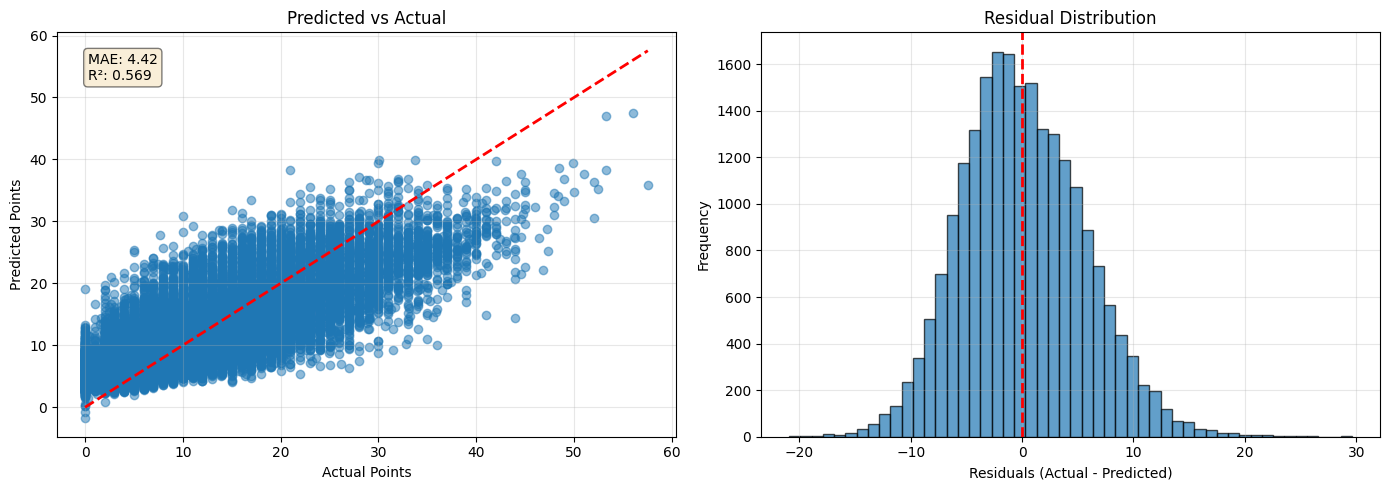

In [6]:
import matplotlib.pyplot as plt


preds_dist = pts_mean.pred_dist(val_df[top_features])
y_pred_mean = preds_dist.loc
y_pred_std = preds_dist.scale
y_true = val_df['PTS'].values

fig, axes = plt.subplots(1, 2, figsize=(14, 5))


axes[0].scatter(y_true, y_pred_mean, alpha=0.5)
axes[0].plot([y_true.min(), y_true.max()], 
             [y_true.min(), y_true.max()], 'r--', lw=2)
axes[0].set_xlabel('Actual Points')
axes[0].set_ylabel('Predicted Points')
axes[0].set_title('Predicted vs Actual')
axes[0].grid(True, alpha=0.3)

mae = mean_absolute_error(y_true, y_pred_mean)
r2 = r2_score(y_true, y_pred_mean)
axes[0].text(0.05, 0.95, f'MAE: {mae:.2f}\nR²: {r2:.3f}', 
             transform=axes[0].transAxes,
             verticalalignment='top',
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

residuals = y_true - y_pred_mean
axes[1].hist(residuals, bins=50, edgecolor='black', alpha=0.7)
axes[1].axvline(x=0, color='r', linestyle='--', lw=2)
axes[1].set_xlabel('Residuals (Actual - Predicted)')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Residual Distribution')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [7]:
import pandas as pd
import numpy as np

mean_importance_raw = pts_mean.feature_importances_  
var_importance_raw = pts_var.feature_importances_    

# Average across the 2 distributions
mean_importance = mean_importance_raw.mean(axis=0)  
var_importance = var_importance_raw.mean(axis=0)    

# NOW create the DataFrame
feature_importance_df = pd.DataFrame({
    'feature': top_features,
    'mean_model': mean_importance,  
    'var_model': var_importance    
}).sort_values('mean_model', ascending=False)

# Display top features
print("\n" + "="*80)
print("TOP 20 FEATURES FOR PREDICTING POINTS (MEAN MODEL)")
print("="*80)
print(feature_importance_df[['feature', 'mean_model']].head(20).to_string(index=False))


TOP 20 FEATURES FOR PREDICTING POINTS (MEAN MODEL)
                   feature  mean_model
           PTS_MAX_LAST_10    0.149772
           PTS_MIN_LAST_10    0.067658
 FGM_VOLATILITY_10_TO_DATE    0.056187
        PTS_ROLLING_AVG_40    0.028453
         GAMES_THIS_SEASON    0.026465
  PTS_VOLATILITY_5_TO_DATE    0.025899
      OPP_GUARD_DEF_RATING    0.025483
      TS_PCT_CV_10_TO_DATE    0.021127
        FGA_ROLLING_AVG_10    0.018941
        EXPECTED_USAGE_MIN    0.016303
FG3M_VOLATILITY_10_TO_DATE    0.015307
          PTS_TREND_LAST_5    0.014099
      PTS_RECENT_VS_SEASON    0.013350
     PTS_PER_MIN_X_MIN_LAG    0.013031
        PTS_DELTA_STAR_OUT    0.012576
       USG_PCT_AVG_TO_DATE    0.010959
    OPP_FORWARD_DEF_RATING    0.010512
                  STARTING    0.009896
        PTS_PER_POSSESSION    0.008895
     FG_PCT_ROLLING_AVG_10    0.008686


In [8]:
print("\n" + "="*80)
print("TOP 20 FEATURES FOR PREDICTING POINTS (VAR MODEL)")
print("="*80)
print(feature_importance_df[['feature', 'var_model']].head(20).to_string(index=False))


TOP 20 FEATURES FOR PREDICTING POINTS (VAR MODEL)
                   feature  var_model
           PTS_MAX_LAST_10   0.316935
           PTS_MIN_LAST_10   0.071277
 FGM_VOLATILITY_10_TO_DATE   0.039778
        PTS_ROLLING_AVG_40   0.003241
         GAMES_THIS_SEASON   0.008402
  PTS_VOLATILITY_5_TO_DATE   0.021655
      OPP_GUARD_DEF_RATING   0.022414
      TS_PCT_CV_10_TO_DATE   0.010640
        FGA_ROLLING_AVG_10   0.020153
        EXPECTED_USAGE_MIN   0.012762
FG3M_VOLATILITY_10_TO_DATE   0.008838
          PTS_TREND_LAST_5   0.009327
      PTS_RECENT_VS_SEASON   0.005929
     PTS_PER_MIN_X_MIN_LAG   0.004917
        PTS_DELTA_STAR_OUT   0.003556
       USG_PCT_AVG_TO_DATE   0.003136
    OPP_FORWARD_DEF_RATING   0.008623
                  STARTING   0.006977
        PTS_PER_POSSESSION   0.006269
     FG_PCT_ROLLING_AVG_10   0.001497


In [9]:
validate_production_model(pts_mean, pts_var, val_df, top_features, 'PTS', calibration_factor)

=== CALIBRATION CHECK ===
Standardized residuals mean: 0.004 (should be ~0)
Standardized residuals std: 0.987 (should be ~1)
Q10: Predicted=5.5, Actual=3.0
Q25: Predicted=8.7, Actual=6.0
Q50: Predicted=12.3, Actual=11.0
Q75: Predicted=15.9, Actual=17.0
Q90: Predicted=19.1, Actual=24.0

MAE: 4.42
90% CI: Coverage=92.76%, Expected=90.00%
95% CI: Coverage=97.63%, Expected=95.00%
99% CI: Coverage=99.55%, Expected=99.00%


array([ 0.09240837, -0.67198752,  0.09031272, ...,  0.09401299,
       -0.88250492,  0.6408115 ], shape=(22104,))

In [10]:
mu, var = predict_mean_variance_split(pts_mean, pts_var, val_df, top_features, calibration_factor)
print(f"Mean predictions: {mu[:5]}")
print(f"Variance predictions: {var[:5]}")

Mean predictions: [ 7.46064709 10.67671012 11.38498585 10.67671012 10.67671012]
Variance predictions: [34.06617681 48.43490857 46.37376113 48.43490857 48.43490857]


In [21]:
# Save NGBoost split models (mean, variance, and calibration factor)
joblib.dump(pts_mean, 'SAVED_MODELS/NGBOOST_PTS_MEAN_MODEL.pkl')
joblib.dump(pts_var, 'SAVED_MODELS/NGBOOST_PTS_VAR_MODEL.pkl')
joblib.dump(calibration_factor, 'SAVED_MODELS/NGBOOST_PTS_CALIBRATION_FACTOR.pkl')

joblib.dump(top_features, 'SAVED_MODELS/feature_list.pkl')

print(f"Saved models with calibration factor: {calibration_factor}")

Saved models with calibration factor: 1.25
